# FTIR Analysis of Honey Samples

This notebook reads ATR-FTIR spectra from the `data/ftir/` folder,
plots a waterfall and overlay of all spectra, then applies PCA.
The data are already baseline-corrected; sample IDs are derived from filenames.


## 0 · Environment setup

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 · Environment setup
# ─────────────────────────────────────────────────────────────────────────────

import sys
from pathlib import Path

try:
    import google.colab      # noqa: F401
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    DATA_DIR   = Path('/content/data/ftir')
    OUTPUT_DIR = Path('/content/data/processed')
    print("\u25b6 Running on Google Colab")
else:
    DATA_DIR   = Path('../data/ftir')
    OUTPUT_DIR = Path('../data/processed')
    print("\u25b6 Running locally")

print(f"   Data directory   : {DATA_DIR.resolve()}")
print(f"   Output directory : {OUTPUT_DIR.resolve()}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("\nOutput directory ready \u2713")


▶ Running locally
   Data directory   : /Users/gunter/Documents/fbmfor-foodfraud/data/ftir
   Output directory : /Users/gunter/Documents/fbmfor-foodfraud/data/processed

Output directory ready ✓


## 1 · Imports

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 · Imports
#
# All packages below are pre-installed in Google Colab and in standard
# scientific Python environments (Anaconda, pip install numpy pandas
# matplotlib scikit-learn).
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np                       # Numerical arrays and vectorised maths
import pandas as pd                      # Reading and manipulating CSV data
import matplotlib.pyplot as plt          # All plotting
import matplotlib.cm as cm               # Colour maps for multi-line spectral plots
from sklearn.decomposition import PCA    # Principal Component Analysis

# Render plots inline (embedded in notebook output cell).
# This works in both Colab and classic Jupyter / JupyterLab.
%matplotlib inline

# ── Global plot style ─────────────────────────────────────────────────────────
# Setting rcParams here once keeps every subsequent figure visually consistent
# without repeating style arguments in each individual plot command.
plt.rcParams.update({
    'figure.dpi'     : 120,   # Screen display resolution
    'savefig.dpi'    : 150,   # Resolution of saved PNG files
    'font.size'      : 11,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'legend.fontsize': 9,
})

print("Imports OK ✓")

Imports OK ✓


## 2 · Load spectra

We read every `.csv` file in `DATA_DIR`.  
The spectra are already baseline-corrected (Perkin-Elmer export).  
Sample IDs are derived from the filename stem, stripping the
`_baselinecorrected` / `_baselineremoved` suffix for brevity.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 · Load spectra
# ─────────────────────────────────────────────────────────────────────────────

import re

def clean_label(stem: str) -> str:
    """Strip baseline-processing suffixes and tidy whitespace."""
    label = re.sub(r'_?basell?ine(removed|corrected)', '', stem,
                   flags=re.IGNORECASE)
    return label.strip('_ ')


def read_ftir_csv(path: Path) -> tuple:
    """
    Read a Perkin-Elmer Spectrum CSV.
    Line 1: instrument metadata
    Line 2: 'cm-1,%T'  (header, skipped)
    Line 3+: wavenumber, %T
    Returns (wavenumbers, absorbance, label).
    """
    df = pd.read_csv(path, skiprows=2, names=['wavenumber', 'pct_T'],
                     encoding='utf-8-sig')
    df['wavenumber'] = pd.to_numeric(df['wavenumber'], errors='coerce')
    df['pct_T']      = pd.to_numeric(df['pct_T'],      errors='coerce')
    df = df.dropna()

    pct_T_safe = np.clip(df['pct_T'].values, 0.01, None)
    absorbance = 2.0 - np.log10(pct_T_safe)   # A = 2 − log10(%T)
    label = clean_label(path.stem)
    return df['wavenumber'].values, absorbance, label


# ── Load all CSV files ────────────────────────────────────────────
csv_files = sorted(DATA_DIR.glob('*.csv'))

if not csv_files:
    raise FileNotFoundError(
        f"No .csv files found in {DATA_DIR.resolve()}\n"
        "Check the DATA_DIR path in Section 0."
    )

# corrected: { sample_label : (wavenumber_array, absorbance_array) }
# (data is already baseline-corrected; no further blank subtraction needed)
corrected = {}

print(f"Loading {len(csv_files)} spectra:\n")
for f in csv_files:
    wn, abs_arr, label = read_ftir_csv(f)
    corrected[label] = (wn, abs_arr)
    print(f"  {label:<35}  ({len(wn)} pts, {wn[-1]:.0f}–{wn[0]:.0f} cm⁻¹)")

wn_example = list(corrected.values())[0][0]
print(f"\nWavenumber axis: {wn_example[-1]:.0f} – {wn_example[0]:.0f} cm⁻¹  "
      f"({len(wn_example)} points)")


Loading 7 spectra:

  Sample 2                             (3551 pts, 650–4200 cm⁻¹)
  sample 6                             (3551 pts, 650–4200 cm⁻¹)
  sample 8                             (3551 pts, 650–4200 cm⁻¹)
  sample CBD_240326_1                  (3551 pts, 650–4200 cm⁻¹)
  sample bc 240326_1                   (3551 pts, 650–4200 cm⁻¹)
  sample10                             (3551 pts, 650–4200 cm⁻¹)
  sample4_240326_1                     (3551 pts, 650–4200 cm⁻¹)

Wavenumber axis: 650 – 4200 cm⁻¹  (3551 points)


## 3 · Pre-processing note

The spectra were exported from Perkin-Elmer Spectrum software with
**baseline correction already applied** (filenames contain
`_baselinecorrected` or `_baselineremoved`).  
No additional blank subtraction is performed here; the `corrected` dict
populated in Section 2 is used directly for all subsequent analysis.

> **%T → Absorbance conversion**: `A = 2 − log₁₀(%T)` (Beer–Lambert law,
> with a 0.01 %T floor to avoid log(0)).


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 · (skipped — data is pre-baseline-corrected)
# corrected dict is already populated in Section 2.
# ─────────────────────────────────────────────────────────────────────────────
print("Data already baseline-corrected; no further pre-processing required.")
print(f"Samples in dataset: {list(corrected.keys())}")


Data already baseline-corrected; no further pre-processing required.
Samples in dataset: ['Sample 2', 'sample 6', 'sample 8', 'sample CBD_240326_1', 'sample bc 240326_1', 'sample10', 'sample4_240326_1']


## 4 · Plot spectra

### Overlay vs waterfall — which to use for FTIR?

| Plot type | When to use | Advantage | Limitation |
|-----------|------------|-----------|------------|
| **Overlay** | Comparing peak positions and relative intensities | Peak heights directly comparable; peak shifts easy to spot | Spectra can overlap and obscure each other |
| **Waterfall (stacked offset)** | Many similar spectra; overlapping lines unreadable | Each trace individually visible | Absolute intensities not comparable across traces |

**Overlay is the standard for food FTIR authentication** in the published literature.
Both are included here; use whichever communicates your data best.

The shaded blue region (1800–650 cm⁻¹) is the **carbohydrate fingerprint** used for PCA.

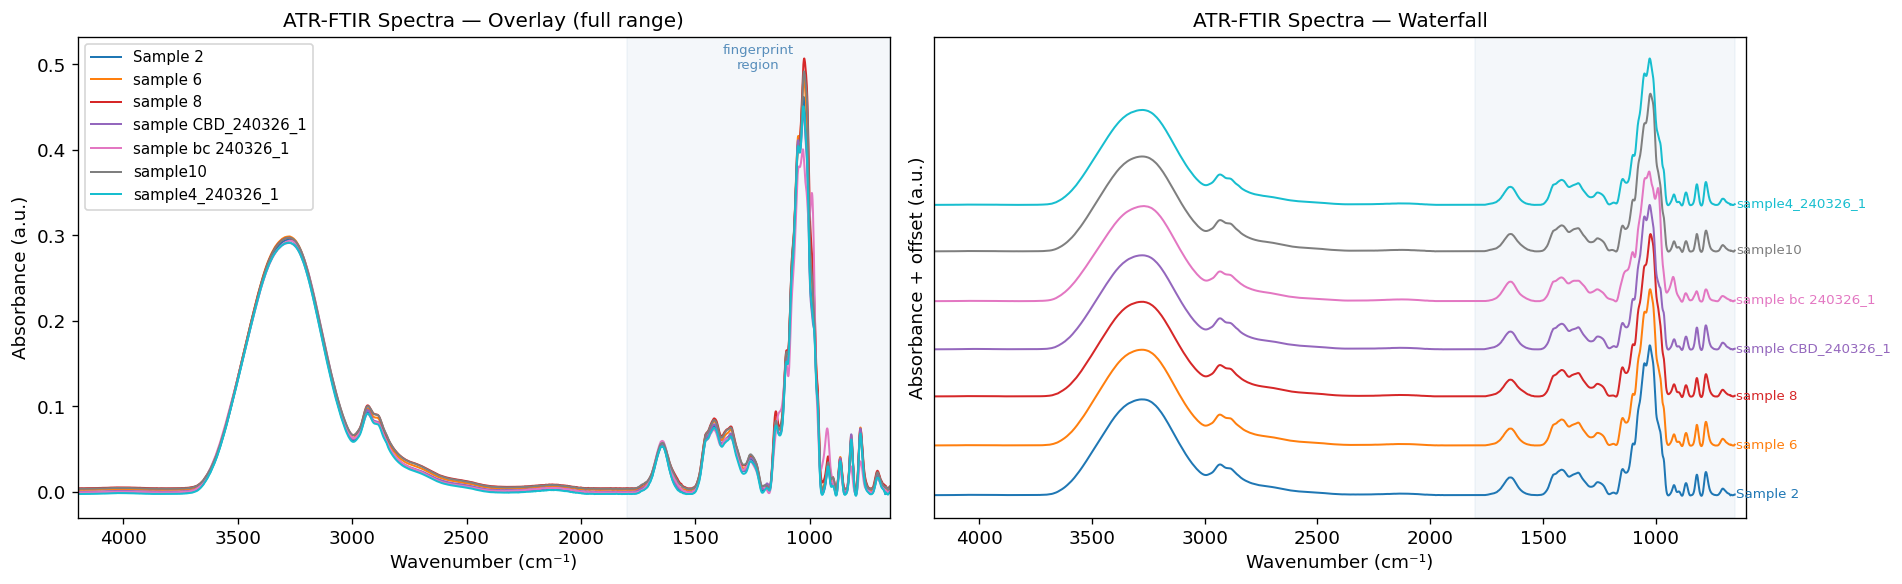

Saved → ../data/processed/honey_ftir_spectra.png


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 · Plot spectra
# Figure 1: Overlay + Waterfall (full spectral range, side by side)
# ─────────────────────────────────────────────────────────────────────────────

n_samples = len(corrected)

# Assign one colour per sample from the 'tab10' qualitative palette.
# np.linspace(0, 0.9, n) spreads n colours evenly across the palette,
# stopping at 0.9 to avoid the grey at the far end (hard to see on white).
# Switch to cm.tab20 if you have more than 10 samples.
colors = cm.tab10(np.linspace(0, 0.9, n_samples))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left panel: Overlay ───────────────────────────────────────────────────────
ax = axes[0]
for (label, (wn, corr)), col in zip(corrected.items(), colors):
    ax.plot(wn, corr, color=col, linewidth=1.2, label=label)

# FTIR convention: x-axis runs HIGH → LOW wavenumber (high energy on left).
# This matches all published reference spectra so readers can compare directly.
ax.invert_xaxis()
ax.set_xlabel('Wavenumber (cm⁻¹)')
ax.set_ylabel('Absorbance (a.u.)')
ax.set_title('ATR-FTIR Spectra — Overlay (full range)')
ax.legend()

# Lightly shade the fingerprint region to orientate the reader.
# alpha=0.06 is almost transparent so it does not obscure the spectra.
ax.axvspan(1800, 650, alpha=0.06, color='steelblue')
ax.text(1225, ax.get_ylim()[1] * 0.93, 'fingerprint\nregion',
        fontsize=8, ha='center', color='steelblue', alpha=0.9)
ax.set_xlim(4200, 650)

# ── Right panel: Waterfall (stacked / offset) ─────────────────────────────────
ax2 = axes[1]

# offset_step: vertical spacing between successive traces.
# Increase if intense spectra overlap even when stacked;
# decrease for flatter spectra where labels go off the top.
offset_step = 0.15

for i, ((label, (wn, corr)), col) in enumerate(zip(corrected.items(), colors)):
    # Each trace is shifted up by i × offset_step
    ax2.plot(wn, corr + i * offset_step, color=col, linewidth=1.2)
    # Label sits just to the right of the rightmost data point.
    # corr[-1] is the absorbance at the lowest wavenumber (≈650 cm⁻¹),
    # which appears on the right of the inverted x-axis.
    ax2.text(645, corr[-1] + i * offset_step, label,
             fontsize=8, va='center', ha='left', color=col)

ax2.invert_xaxis()
ax2.set_xlabel('Wavenumber (cm⁻¹)')
ax2.set_ylabel('Absorbance + offset (a.u.)')
ax2.set_title('ATR-FTIR Spectra — Waterfall')
ax2.set_xlim(4200, 600)   # extra right margin to fit text labels
ax2.axvspan(1800, 650, alpha=0.06, color='steelblue')
ax2.set_yticks([])         # offset values are meaningless; hide y ticks

plt.tight_layout()
out_path = OUTPUT_DIR / 'honey_ftir_spectra.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

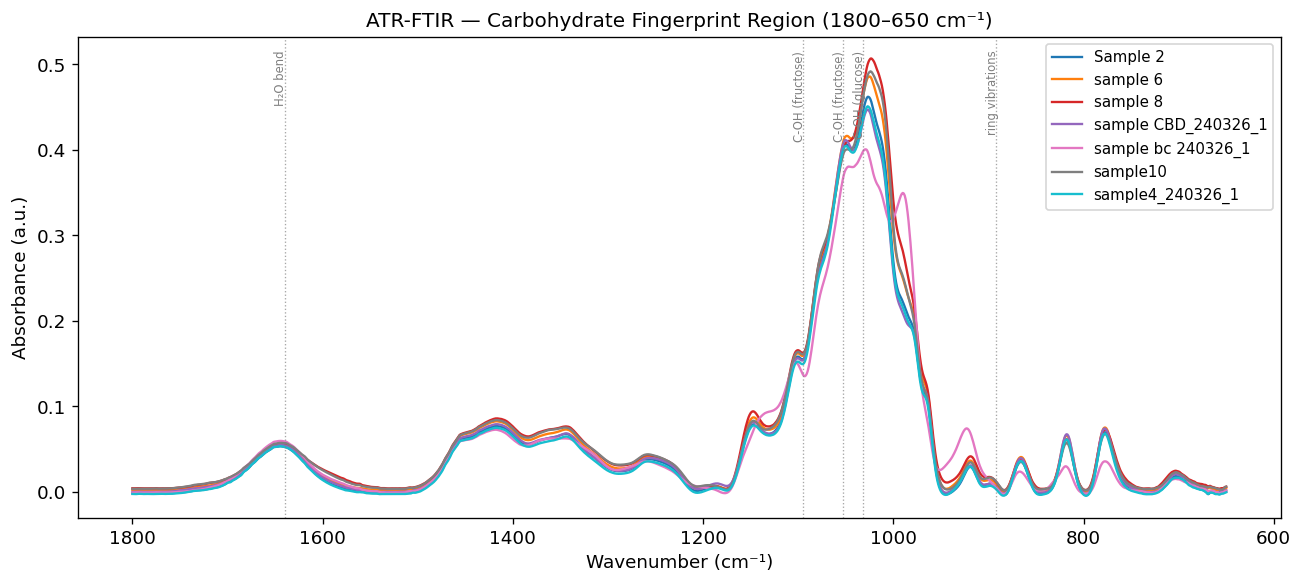

Saved → ../data/processed/honey_ftir_fingerprint.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Fingerprint region only (1800–650 cm⁻¹)
#
# Zooming in reveals the fine structure that differentiates honey varieties
# and detects adulteration.  
# Szaniawska A et al. Data-Driven FTIR Spectroscopy for the Discrimination of Nectars. 
# Molecules. 2025 Oct 14;30(20):4083. 
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))

for (label, (wn, corr)), col in zip(corrected.items(), colors):
    # Boolean mask selects only wavenumber points inside the fingerprint region.
    # This is robust even if the axis does not start or end exactly on 650/1800.
    mask = (wn >= 650) & (wn <= 1800)
    ax.plot(wn[mask], corr[mask], color=col, linewidth=1.4, label=label)

ax.invert_xaxis()   # FTIR convention: high → low
ax.set_xlabel('Wavenumber (cm⁻¹)')
ax.set_ylabel('Absorbance (a.u.)')
ax.set_title('ATR-FTIR — Carbohydrate Fingerprint Region (1800–650 cm⁻¹)')
ax.legend()

# ── Annotate diagnostic honey bands ──────────────────────────────────────────
# Dict maps wavenumber (cm⁻¹) to chemical assignment text.
# The dotted vertical lines help students trace a visible peak to its origin.
bands = {
    1640: 'H₂O bend',
    1095: 'C-OH (fructose)',
    1053: 'C-OH (fructose)',    
    1032: 'C-OH (glucose)',
     892: 'ring vibrations',
}
for wnum, blabel in bands.items():
    ax.axvline(wnum, color='grey', linestyle=':', linewidth=0.8, alpha=0.7)
    # Rotated label just below the top; ha='right' keeps text left of the line
    ax.text(wnum - 3, ax.get_ylim()[1] * 0.97, blabel,
            rotation=90, fontsize=7, va='top', ha='right', color='grey')

plt.tight_layout()
out_path = OUTPUT_DIR / 'honey_ftir_fingerprint.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

## 5 · Principal Component Analysis (PCA)

### Why PCA for FTIR?

Each spectrum has ~1150 wavenumber points in the fingerprint region — far too many to visualise or interpret directly. PCA finds linear combinations of wavenumber channels (principal components, PCs) that capture the most variance across all spectra.
It compresses the high-dimensional data into 2–3 dimensions while retaining the key chemical differences.

| Output | Interpretation |
|--------|---------------|
| **Scores plot** (PC1 vs PC2) | Each spectrum = one point. Clusters = similar chemistry. Separation = real chemical differences. |
| **Loadings plot** | Which wavenumbers drive each PC. Peaks = channels with discriminating power. |
| **Biplot** | Scores and loading vectors in one figure. Arrows point towards samples with high absorbance at that wavenumber. |

### Pre-processing: mean-centring only

We **mean-centre** (subtract the column mean) but do **not** autoscale (divide by the column standard deviation) because flat spectral regions have near-zero standard deviations, and dividing by them would amplify noise to the same level as real peaks.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 · PCA — build data matrix, mean-centre, decompose
# ─────────────────────────────────────────────────────────────────────────────

# ── Spectral region for PCA ───────────────────────────────────────────────────
# Using 1800–650 cm⁻¹ (fingerprint):
#   ✓ Contains the most diagnostic sugar bands
#   ✗ Excludes the broad water O-H stretch (3600–2800 cm⁻¹) which would
#     dominate variance and mask the more informative sugar signals
FP_LOW, FP_HIGH = 650, 1800   # cm⁻¹

# All corrected spectra share the same wavenumber axis; take the first one
labels_list = list(corrected.keys())
wn_first    = corrected[labels_list[0]][0]

# Boolean mask: True for wavenumbers inside the fingerprint region
fp_mask = (wn_first >= FP_LOW) & (wn_first <= FP_HIGH)
wn_fp   = wn_first[fp_mask]   # wavenumber axis for fingerprint region

# ── Assemble the data matrix X ────────────────────────────────────────────────
# Shape: (n_samples, n_wavenumber_points)
# np.array() converts a list of 1-D arrays into a 2-D array by stacking rows.
X = np.array([corr[fp_mask] for _, (wn, corr) in corrected.items()])

print(f"Data matrix X : {X.shape[0]} samples × {X.shape[1]} wavenumber points")

# ── Mean-centring ─────────────────────────────────────────────────────────────
# Subtract the column-wise mean spectrum.
# X.mean(axis=0) → shape (n_features,) which is broadcast over all rows.
X_mc = X - X.mean(axis=0)

# ── PCA ──────────────────────────────────────────────────────────────────────
# PCA cannot produce more non-trivial components than there are samples,
# so we cap n_components at the number of samples.
n_components = min(len(labels_list), 5)
pca    = PCA(n_components=n_components)
# fit_transform:
#   fit      – computes the PC directions (eigenvectors) from X_mc
#   transform – projects each sample onto those directions → score values
scores = pca.fit_transform(X_mc)   # shape: (n_samples, n_components)

explained = pca.explained_variance_ratio_ * 100   # as percentage

print("\nVariance explained per PC:")
for i, ev in enumerate(explained):
    print(f"  PC{i+1}: {ev:5.1f}%  {'█' * int(ev/2)}")
print(f"\n  Cumulative (PC1–PC{n_components}): {explained.sum():.1f}%")

Data matrix X : 7 samples × 1151 wavenumber points

Variance explained per PC:
  PC1:  61.0%  ██████████████████████████████
  PC2:  36.6%  ██████████████████
  PC3:   1.2%  
  PC4:   0.9%  
  PC5:   0.2%  

  Cumulative (PC1–PC5): 99.9%


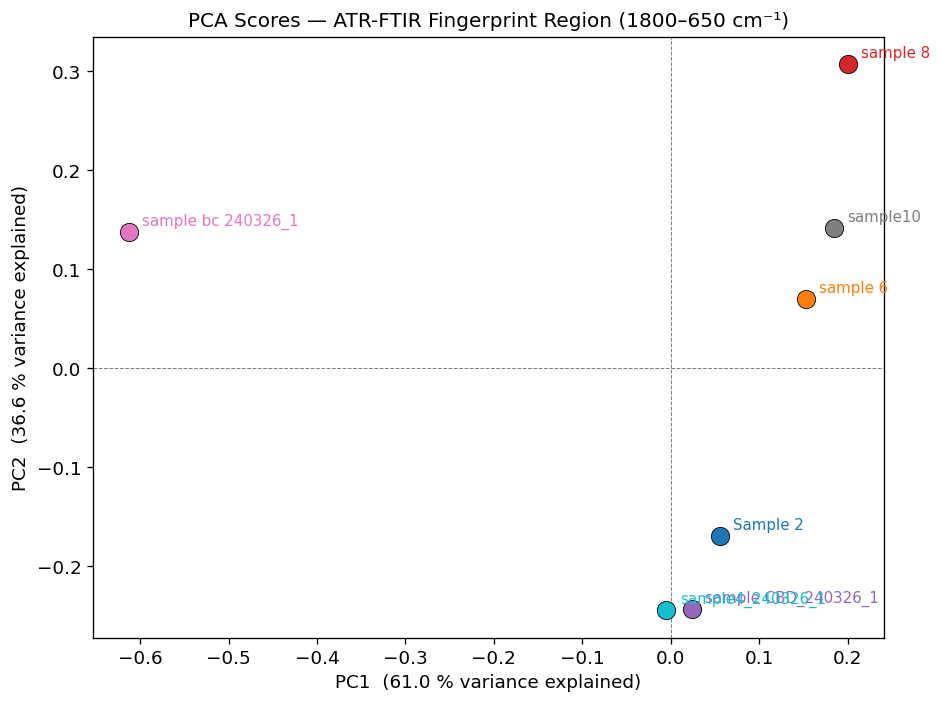

Saved → ../data/processed/honey_pca_scores.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: PCA Scores plot  (PC1 vs PC2)
#
# Each point = one honey sample projected onto the first two principal components.
# Samples that are chemically similar cluster together.
# The axes are dimensionless 'score' units; their meaning comes from the loadings.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for i, (label, col) in enumerate(zip(labels_list, colors)):
    # zorder=3 draws markers above grid lines
    # edgecolors='k' adds a thin black outline so light colours remain visible
    ax.scatter(scores[i, 0], scores[i, 1],
               color=col, s=120, zorder=3, edgecolors='k', linewidths=0.5)
    # Offset the label slightly (8 pt right, 4 pt up) to avoid overlapping the marker
    ax.annotate(label, (scores[i, 0], scores[i, 1]),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=col)

# Cross-hairs at the origin (= mean spectrum after mean-centring)
ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')

# Axis labels include % variance explained so readers see the relative importance
ax.set_xlabel(f'PC1  ({explained[0]:.1f} % variance explained)')
ax.set_ylabel(f'PC2  ({explained[1]:.1f} % variance explained)')
ax.set_title('PCA Scores — ATR-FTIR Fingerprint Region (1800–650 cm⁻¹)')

plt.tight_layout()
out_path = OUTPUT_DIR / 'honey_pca_scores.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

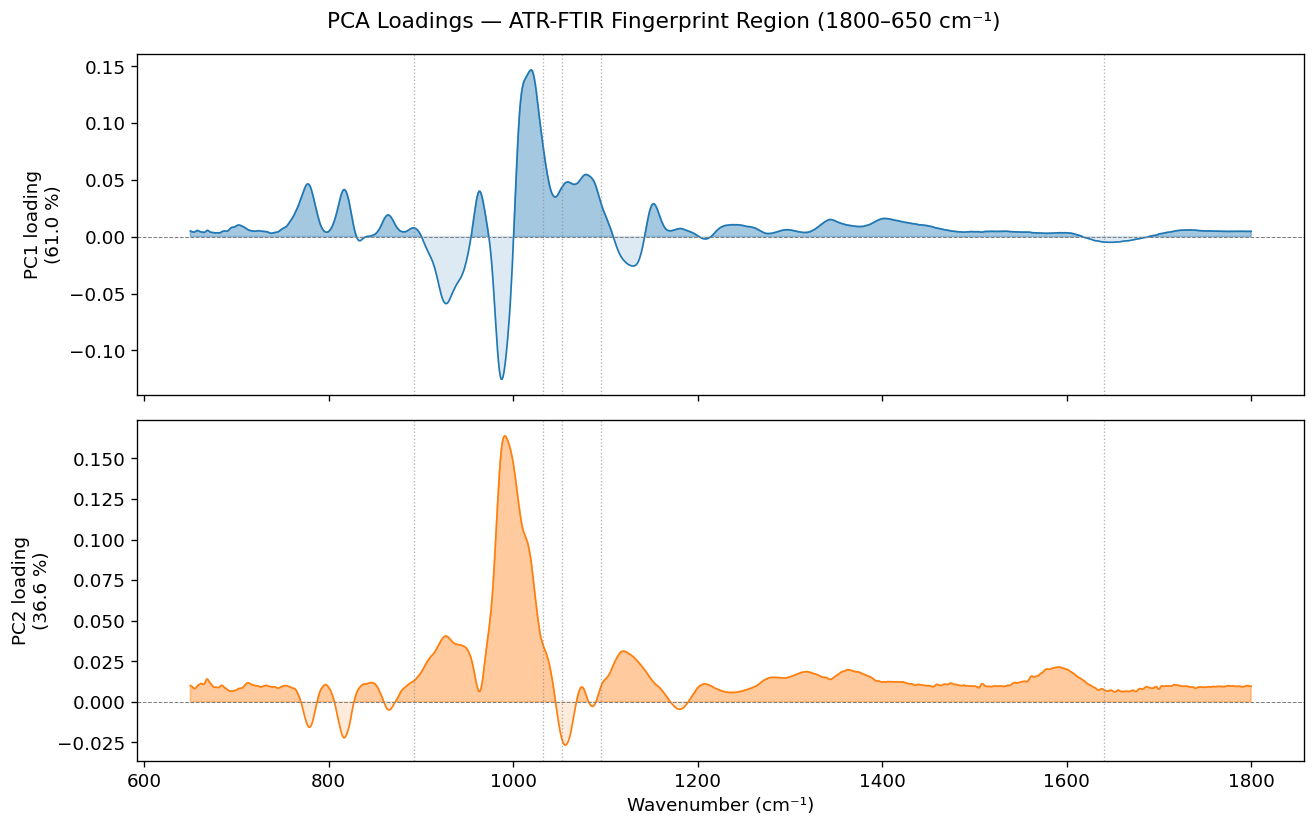

Saved → ../data/processed/honey_pca_loadings.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: PCA Loadings plot  (PC1 and PC2 plotted as spectra)
#
# A loading has one value per wavenumber channel.  Plotted against wavenumber
# it looks like a spectrum and reveals which parts of the infrared range drive
# the separation seen in the scores plot:
#   Positive loading → high absorbance here pushes a sample towards the +PC end
#   Negative loading → high absorbance here pushes a sample towards the −PC end
#
# Overlaying the same band markers as Figure 2 enables direct chemical assignment.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(11, 7),
                          sharex=True)   # linked x-axis: zoom one panel zooms both

for pc_idx, ax in enumerate(axes):
    loading = pca.components_[pc_idx]   # shape (n_wavenumber_points,)

    # Filled regions make the sign of each feature visually obvious at a glance.
    # Using the same colour for both lobes (different alpha) keeps the palette tidy.
    ax.fill_between(wn_fp, loading, 0,
                    where=(loading >= 0), color=f'C{pc_idx}', alpha=0.4)
    ax.fill_between(wn_fp, loading, 0,
                    where=(loading < 0),  color=f'C{pc_idx}', alpha=0.15)
    ax.plot(wn_fp, loading, color=f'C{pc_idx}', linewidth=1.0)

    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_ylabel(f'PC{pc_idx + 1} loading\n({explained[pc_idx]:.1f} %)')
    ax.invert_xaxis()

    # Overlay the diagnostic band markers from Figure 2 for cross-reference
    for wnum in bands.keys():
        if FP_LOW <= wnum <= FP_HIGH:
            ax.axvline(wnum, color='grey', linestyle=':', linewidth=0.8, alpha=0.6)

axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
fig.suptitle('PCA Loadings — ATR-FTIR Fingerprint Region (1800–650 cm⁻¹)', fontsize=13)

plt.tight_layout()
out_path = OUTPUT_DIR / 'honey_pca_loadings.png'
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

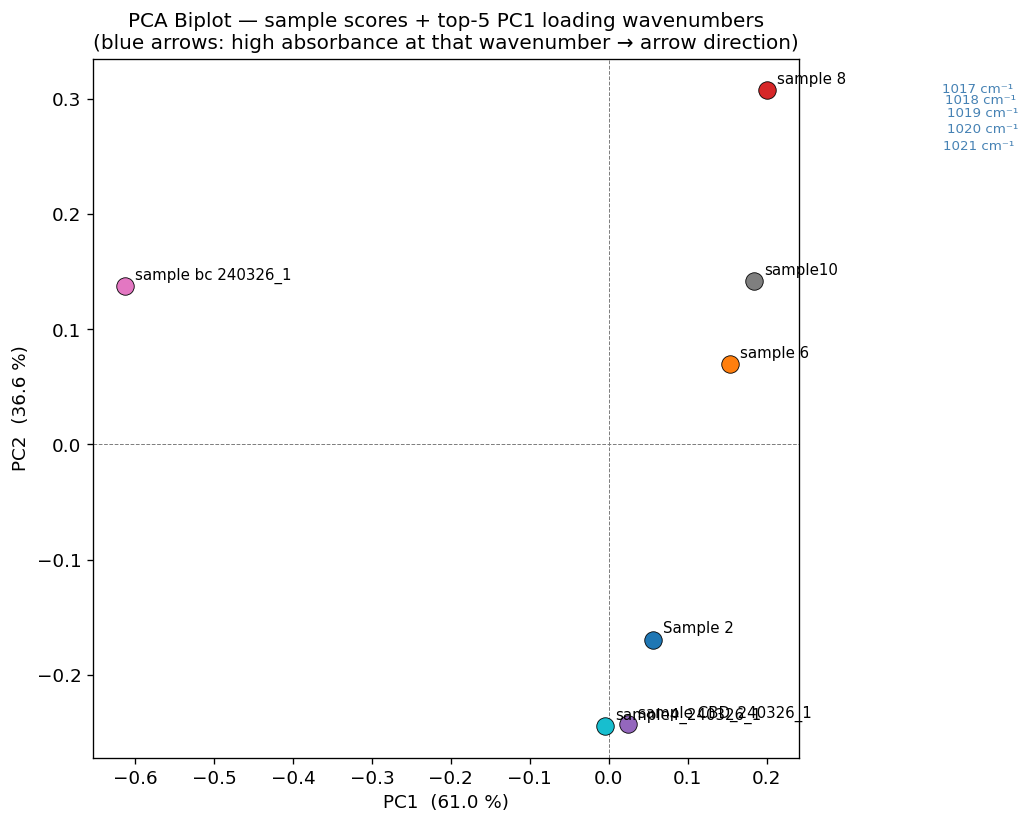

Saved → ../data/processed/honey_pca_biplot.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 5: PCA Biplot  (scores + top loading vectors)
#
# The biplot overlays the sample scores (dots) with arrows showing which
# wavenumber channels drive the separation.  An arrow pointing towards a
# cluster of samples means those samples have high absorbance at that wavenumber.
#
# Only the 5 channels with the largest absolute PC1 loading are drawn to avoid
# clutter.  This figure is most meaningful with ≥ 4 samples.
# ─────────────────────────────────────────────────────────────────────────────

if len(labels_list) < 4:
    print("Biplot skipped — need ≥ 4 samples for a meaningful biplot.")
    print("Add more sample CSV files to DATA_DIR and re-run the notebook.")
else:
    fig, ax = plt.subplots(figsize=(9, 7))

    # ── Sample scores ─────────────────────────────────────────────────────────
    for i, (label, col) in enumerate(zip(labels_list, colors)):
        ax.scatter(scores[i, 0], scores[i, 1],
                   color=col, s=110, zorder=3, edgecolors='k', linewidths=0.5)
        ax.annotate(label, (scores[i, 0], scores[i, 1]),
                    textcoords='offset points', xytext=(6, 4), fontsize=9)

    # ── Scale loading vectors to fit the scores axes ───────────────────────────
    # Scores and loadings have different units.  We rescale so the longest arrow
    # reaches ~80 % of the maximum score distance from the origin.
    # This is purely cosmetic and does not change which channels are important.
    score_range   = np.max(np.abs(scores[:, :2]))
    loading_range = np.max(np.abs(pca.components_[:2]))
    scale = (0.8 * score_range / loading_range) if loading_range > 0 else 1.0

    # ── Top-5 most influential wavenumber vectors (by |PC1 loading|) ──────────
    # np.argsort returns indices in ascending order; [-5:] takes the last five.
    top5_idx = np.argsort(np.abs(pca.components_[0]))[-5:]

    for idx in top5_idx:
        lx = pca.components_[0, idx] * scale   # scaled x-component
        ly = pca.components_[1, idx] * scale   # scaled y-component
        # Arrow from origin to loading vector tip
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.8))
        # Label just beyond the arrowhead (factor 1.08 nudges it past the tip)
        ax.text(lx * 1.08, ly * 1.08, f'{wn_fp[idx]:.0f} cm⁻¹',
                fontsize=8, color='steelblue', ha='center')

    ax.axhline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.6, linestyle='--')
    ax.set_xlabel(f'PC1  ({explained[0]:.1f} %)')
    ax.set_ylabel(f'PC2  ({explained[1]:.1f} %)')
    ax.set_title('PCA Biplot — sample scores + top-5 PC1 loading wavenumbers\n'
                 '(blue arrows: high absorbance at that wavenumber → arrow direction)')

    plt.tight_layout()
    out_path = OUTPUT_DIR / 'honey_pca_biplot.png'
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")

## 6 · Summary

| Step | Choice | Rationale |
|------|--------|-----------|
| Unit conversion | %T → Absorbance | Linear with concentration (Beer–Lambert) |
| Baseline correction | Pre-applied by instrument software | Spectra exported as baseline-corrected |
| Blank subtraction | None | No blank files present; pre-processing sufficient |
| Sample ID | Filename stem (suffix stripped) | Unambiguous, reproducible |
| Spectral range for PCA | 1800–650 cm⁻¹ (fingerprint) | Most diagnostic for honey sugars |
| PCA pre-processing | Mean-centring | Standard for spectral PCA |
